In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Učitavanje podataka
df = pd.read_csv("nekretnine_dataset.csv")

# Osnovne informacije
print("=== OBLIK DATASETA ===")
print(f"Redova: {df.shape[0]}, Kolona: {df.shape[1]}")

print("\n=== PRVIH 5 REDOVA ===")
print(df.head())

print("\n=== TIPOVI PODATAKA ===")
print(df.dtypes)

print("\n=== NEDOSTAJUĆE VREDNOSTI ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"Broj": missing, "Procenat (%)": missing_pct})[missing > 0])

print("\n=== OSNOVNE STATISTIKE ===")
print(df.describe())

=== OBLIK DATASETA ===
Redova: 5000, Kolona: 12

=== PRVIH 5 REDOVA ===
   Area_m2  YearBuilt Furnished Renovated      Location PropertyType  \
0    107.0     2006.0       Yes        No  Novi Beograd         Stan   
1     64.9     1991.0       Yes        No    Predgradje         Stan   
2     44.5     1974.0        No        No         Zemun       Studio   
3     68.1     1990.0        No        No         Zemun         Stan   
4     51.2     1990.0        No       Yes        Centar       Studio   

  HasBasement  ParkingSpaces  Bedrooms  Bathrooms Condition   Price  
0          No            2.0         4          1      Good  258900  
1          No            1.0         4          1      Fair   79200  
2         Yes            1.0         2          3      Fair   63400  
3          No            1.0         3          2      Good  128700  
4         Yes            0.0         1          2      Good  110700  

=== TIPOVI PODATAKA ===
Area_m2          float64
YearBuilt        float64


In [3]:
# ============================================================
# KORAK 2: ČIŠĆENJE PODATAKA
# ============================================================

print("=== PRE ČIŠĆENJA ===")
print(f"Broj redova: {len(df)}")

# --- 1. Uklanjanje outliera ---
# Realne granice za nekretnine
df = df[df["Price"].between(20000, 700000)]
df = df[df["Area_m2"].between(15, 350)]

print(f"Broj redova nakon uklanjanja outliera: {len(df)}")

# --- 2. Popunjavanje nedostajućih vrednosti ---

# YearBuilt - popuni medijanom (numerička kolona)
median_year = df["YearBuilt"].median()
df["YearBuilt"] = df["YearBuilt"].fillna(median_year)
print(f"\nYearBuilt - popunjeno medijanom: {median_year}")

# ParkingSpaces - popuni medijanom
median_parking = df["ParkingSpaces"].median()
df["ParkingSpaces"] = df["ParkingSpaces"].fillna(median_parking)

# Furnished - popuni modom (najčešća vrednost)
mode_furnished = df["Furnished"].mode()[0]
df["Furnished"] = df["Furnished"].fillna(mode_furnished)
print(f"Furnished - popunjeno modom: {mode_furnished}")

# Condition - popuni modom
mode_condition = df["Condition"].mode()[0]
df["Condition"] = df["Condition"].fillna(mode_condition)
print(f"Condition - popunjeno modom: {mode_condition}")

# --- 3. Provera ---
print("\n=== NEDOSTAJUĆE VREDNOSTI NAKON ČIŠĆENJA ===")
print(df.isnull().sum())

print("\n=== POSLE ČIŠĆENJA ===")
print(f"Broj redova: {len(df)}")
print(df.describe())

=== PRE ČIŠĆENJA ===
Broj redova: 5000
Broj redova nakon uklanjanja outliera: 4975

YearBuilt - popunjeno medijanom: 1987.0
Furnished - popunjeno modom: No
Condition - popunjeno modom: Good

=== NEDOSTAJUĆE VREDNOSTI NAKON ČIŠĆENJA ===
Area_m2          0
YearBuilt        0
Furnished        0
Renovated        0
Location         0
PropertyType     0
HasBasement      0
ParkingSpaces    0
Bedrooms         0
Bathrooms        0
Condition        0
Price            0
dtype: int64

=== POSLE ČIŠĆENJA ===
Broj redova: 4975
           Area_m2    YearBuilt  ParkingSpaces     Bedrooms    Bathrooms  \
count  4975.000000  4975.000000    4975.000000  4975.000000  4975.000000   
mean     65.900945  1986.490452       0.955176     2.581709     1.635377   
std      24.294102    20.711681       0.849206     1.057508     0.699901   
min      20.000000  1950.000000       0.000000     1.000000     1.000000   
25%      48.500000  1969.000000       0.000000     2.000000     1.000000   
50%      65.500000  1987.

In [4]:
# ============================================================
# KORAK 3: ENKODIRANJE KATEGORIČKIH ATRIBUTA (Bezbedna verzija)
# ============================================================

# --- 1. Binary enkodiranje (Preko .replace da se izbegne stvaranje NaN vrednosti) ---
binary_cols = ["Furnished", "Renovated", "HasBasement"]
for col in binary_cols:
    df[col] = df[col].replace({"Yes": 1, "No": 0})

# --- 2. Ordinalno enkodiranje (Zadržava prirodni redosled) ---
condition_order = {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4}
df["Condition"] = df["Condition"].replace(condition_order)

# --- 3. One-Hot enkodiranje (Za lokaciju i tip nekretnine) ---
df = pd.get_dummies(df, columns=["Location", "PropertyType"], drop_first=True)

# Konvertovanje True/False u 1/0 za stabilnost u svim verzijama pandas-a
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

# --- 4. Pregled rezultata ---
print("=== KOLONE NAKON ENKODIRANJA ===")
print(df.columns.tolist())
print(f"\nOblik dataseta: {df.shape}")
print("\nPrva 3 reda nakon enkodiranja:")
print(df.head(3))

=== KOLONE NAKON ENKODIRANJA ===
['Area_m2', 'YearBuilt', 'Furnished', 'Renovated', 'HasBasement', 'ParkingSpaces', 'Bedrooms', 'Bathrooms', 'Condition', 'Price', 'Location_Novi Beograd', 'Location_Periferia', 'Location_Predgradje', 'Location_Vracar', 'Location_Zemun', 'PropertyType_Stan', 'PropertyType_Studio', 'PropertyType_Vila']

Oblik dataseta: (4975, 18)

Prva 3 reda nakon enkodiranja:
   Area_m2  YearBuilt Furnished Renovated HasBasement  ParkingSpaces  \
0    107.0     2006.0         1         0           0            2.0   
1     64.9     1991.0         1         0           0            1.0   
2     44.5     1974.0         0         0           1            1.0   

   Bedrooms  Bathrooms Condition   Price  Location_Novi Beograd  \
0         4          1         3  258900                      1   
1         4          1         2   79200                      0   
2         2          3         2   63400                      0   

   Location_Periferia  Location_Predgradje  Loc

In [5]:
# Konvertuj True/False u 1/0
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print("=== PROVERA ===")
print(df.head(3))
print(f"\nTipovi podataka:\n{df.dtypes}")

=== PROVERA ===
   Area_m2  YearBuilt Furnished Renovated HasBasement  ParkingSpaces  \
0    107.0     2006.0         1         0           0            2.0   
1     64.9     1991.0         1         0           0            1.0   
2     44.5     1974.0         0         0           1            1.0   

   Bedrooms  Bathrooms Condition   Price  Location_Novi Beograd  \
0         4          1         3  258900                      1   
1         4          1         2   79200                      0   
2         2          3         2   63400                      0   

   Location_Periferia  Location_Predgradje  Location_Vracar  Location_Zemun  \
0                   0                    0                0               0   
1                   0                    1                0               0   
2                   0                    0                0               1   

   PropertyType_Stan  PropertyType_Studio  PropertyType_Vila  
0                  1                    0     

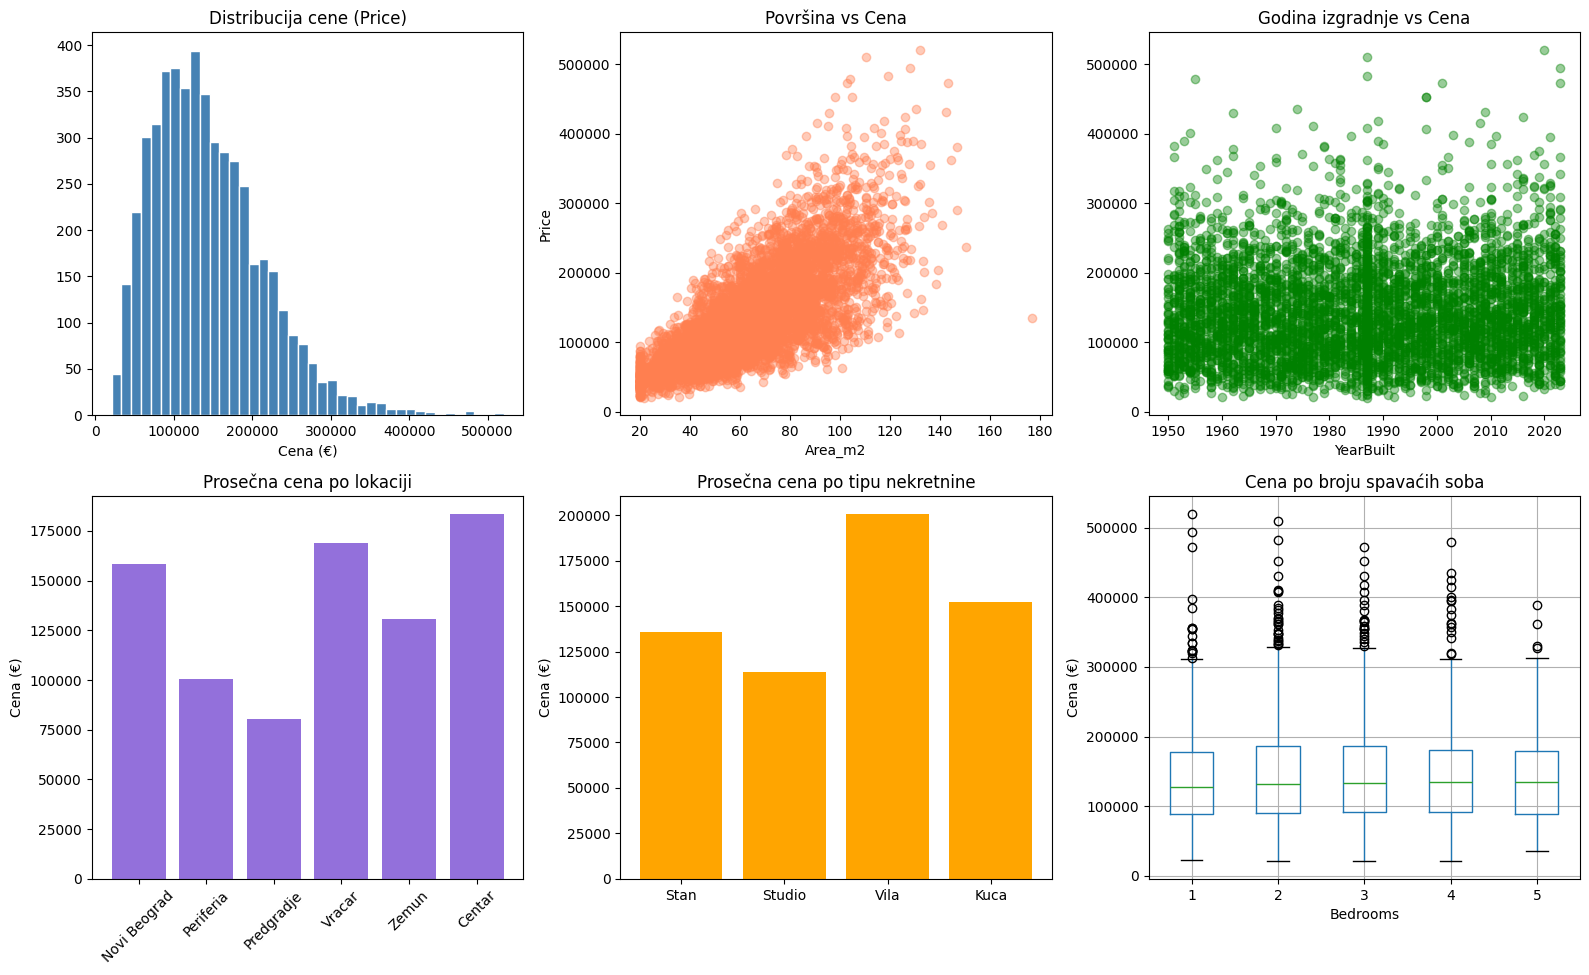

In [6]:
# ============================================================
# KORAK 4: EKSPLORATIVNA ANALIZA (EDA)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribucija ključnih atributa", fontsize=16)

# 1. Distribucija cene
axes[0,0].hist(df["Price"], bins=40, color="steelblue", edgecolor="white")
axes[0,0].set_title("Distribucija cene (Price)")
axes[0,0].set_xlabel("Cena (€)")

# 2. Površina vs Cena
axes[0,1].scatter(df["Area_m2"], df["Price"], alpha=0.4, color="coral")
axes[0,1].set_title("Površina vs Cena")
axes[0,1].set_xlabel("Area_m2")
axes[0,1].set_ylabel("Price")

# 3. Godina izgradnje vs Cena
axes[0,2].scatter(df["YearBuilt"], df["Price"], alpha=0.4, color="green")
axes[0,2].set_title("Godina izgradnje vs Cena")
axes[0,2].set_xlabel("YearBuilt")

# 4. Prosečna cena po lokaciji
location_cols = [c for c in df.columns if c.startswith("Location_")]
location_means = {}
for col in location_cols:
    name = col.replace("Location_", "")
    location_means[name] = df[df[col] == 1]["Price"].mean()
# Dodaj Centar (drop_first ga je uklonio kao referentnu kategoriju)
location_means["Centar"] = df[
    (df[location_cols] == 0).all(axis=1)
]["Price"].mean()

axes[1,0].bar(location_means.keys(), location_means.values(), color="mediumpurple")
axes[1,0].set_title("Prosečna cena po lokaciji")
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylabel("Cena (€)")

# 5. Prosečna cena po tipu nekretnine
type_cols = [c for c in df.columns if c.startswith("PropertyType_")]
type_means = {}
for col in type_cols:
    name = col.replace("PropertyType_", "")
    type_means[name] = df[df[col] == 1]["Price"].mean()
type_means["Kuca"] = df[(df[type_cols] == 0).all(axis=1)]["Price"].mean()

axes[1,1].bar(type_means.keys(), type_means.values(), color="orange")
axes[1,1].set_title("Prosečna cena po tipu nekretnine")
axes[1,1].set_ylabel("Cena (€)")

# 6. Boxplot - Cena po broju soba
df.boxplot(column="Price", by="Bedrooms", ax=axes[1,2])
axes[1,2].set_title("Cena po broju spavaćih soba")
axes[1,2].set_xlabel("Bedrooms")
axes[1,2].set_ylabel("Cena (€)")
plt.suptitle("")

plt.tight_layout()
plt.show()

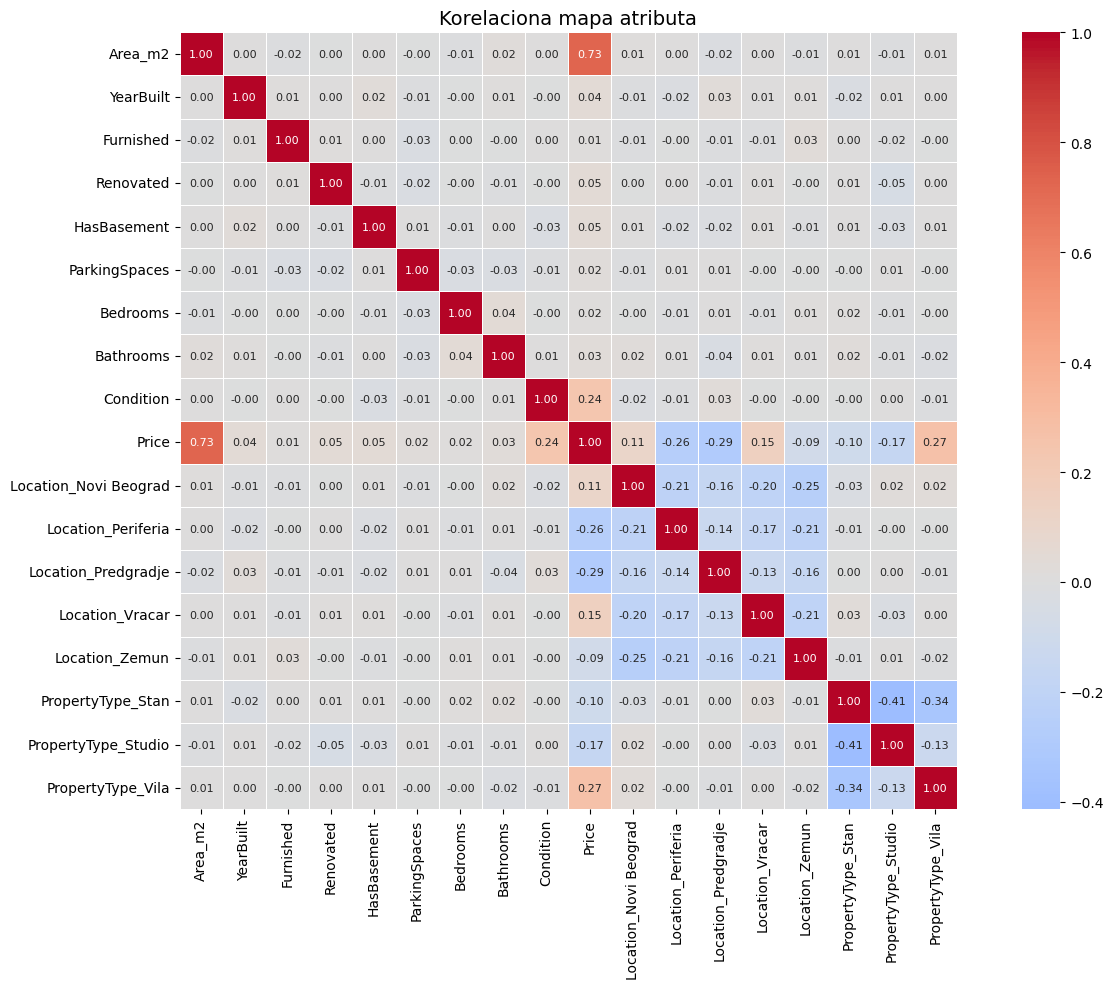

=== KORELACIJA SA CENOM (Price) ===
Area_m2                  0.730
PropertyType_Vila        0.266
Condition                0.243
Location_Vracar          0.150
Location_Novi Beograd    0.108
HasBasement              0.049
Renovated                0.049
YearBuilt                0.044
Bathrooms                0.027
ParkingSpaces            0.022
Bedrooms                 0.016
Furnished                0.015
Location_Zemun          -0.091
PropertyType_Stan       -0.105
PropertyType_Studio     -0.170
Location_Periferia      -0.256
Location_Predgradje     -0.290
Name: Price, dtype: float64


In [7]:
# ============================================================
# KORAK 5: KORELACIONA ANALIZA
# ============================================================

plt.figure(figsize=(14, 10))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Korelaciona mapa atributa", fontsize=14)
plt.tight_layout()
plt.show()

# Korelacija sa cenom - sortirano
print("=== KORELACIJA SA CENOM (Price) ===")
price_corr = corr_matrix["Price"].drop("Price").sort_values(ascending=False)
print(price_corr.round(3))

In [8]:
# ============================================================
# KORAK 6: PRIPREMA PODATAKA I TRENIRANJE MODELA
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Odvajanje features i targeta ---
X = df.drop(columns=["Price"])
y = df["Price"]

# --- Train/Test split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train set: {X_train.shape[0]} redova")
print(f"Test set:  {X_test.shape[0]} redova")

# --- Skaliranje (bitno za Linear Regression) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# --- Treniranje 3 modela ---
models = {
    "Linear Regression":     LinearRegression(),
    "Random Forest":         RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":     GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    # Linear Regression koristi skaliranje, ostali ne trebaju
    if name == "Linear Regression":
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2   = r2_score(y_test, y_pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"\n{name}:")
    print(f"  MAE  = {mae:,.0f} €")
    print(f"  RMSE = {rmse:,.0f} €")
    print(f"  R²   = {r2:.4f}")

Train set: 3980 redova
Test set:  995 redova

Linear Regression:
  MAE  = 14,557 €
  RMSE = 20,074 €
  R²   = 0.9222

Random Forest:
  MAE  = 10,333 €
  RMSE = 13,993 €
  R²   = 0.9622

Gradient Boosting:
  MAE  = 10,802 €
  RMSE = 15,357 €
  R²   = 0.9545


In [9]:
# ============================================================
# KORAK 7: PODEŠAVANJE HIPERPARAMETARA (GridSearchCV)
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":   [100, 200],
    "max_depth":      [3, 5],
    "learning_rate":  [0.05, 0.1],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("=== NAJBOLJI HIPERPARAMETRI ===")
print(grid_search.best_params_)
print(f"\nNajbolji R² na cross-validaciji: {grid_search.best_score_:.4f}")

# Evaluacija najboljeg modela na test setu
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_best)
rmse = mean_squared_error(y_test, y_pred_best) ** 0.5
r2   = r2_score(y_test, y_pred_best)

print("\n=== REZULTATI NAJBOLJEG MODELA NA TEST SETU ===")
print(f"  MAE  = {mae:,.0f} €")
print(f"  RMSE = {rmse:,.0f} €")
print(f"  R²   = {r2:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
=== NAJBOLJI HIPERPARAMETRI ===
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}

Najbolji R² na cross-validaciji: 0.9686

=== REZULTATI NAJBOLJEG MODELA NA TEST SETU ===
  MAE  = 8,295 €
  RMSE = 11,348 €
  R²   = 0.9752


=== 10-FOLD CROSS VALIDACIJA ===

R²  po foldovima: [0.9788 0.972  0.9745 0.9676 0.9761 0.9755 0.9726 0.9703 0.9712 0.9699]
Prosečan R²  = 0.9729 ± 0.0032

MAE po foldovima: [8138. 8568. 8427. 8859. 8071. 8297. 8306. 8509. 8902. 8417.]
Prosečan MAE = 8,449 € ± 260 €

RMSE po foldovima: [10565. 11640. 11833. 12549. 10820. 10780. 11434. 11802. 12358. 11488.]
Prosečan RMSE = 11,527 € ± 625 €


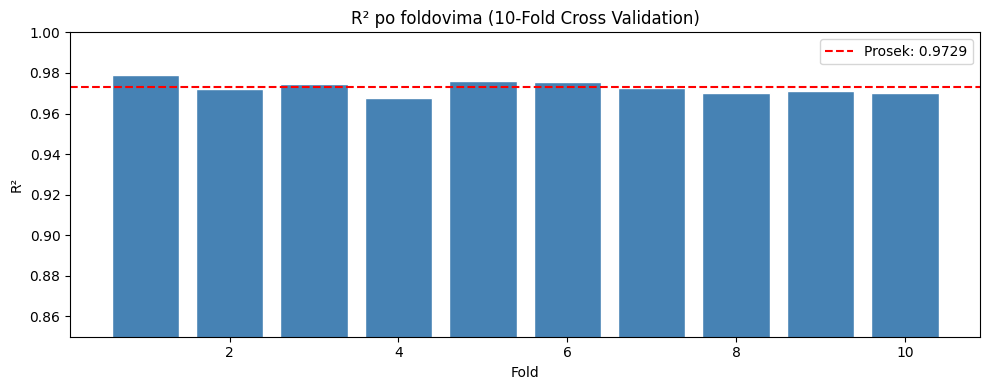

In [10]:
# ============================================================
# KORAK 8: UNAKRSNA VALIDACIJA (Cross-Validation)
# ============================================================

from sklearn.model_selection import cross_val_score

cv_r2   = cross_val_score(best_model, X, y, cv=10, scoring="r2", n_jobs=-1)
cv_mae  = cross_val_score(best_model, X, y, cv=10, scoring="neg_mean_absolute_error", n_jobs=-1)
cv_rmse = cross_val_score(best_model, X, y, cv=10, scoring="neg_root_mean_squared_error", n_jobs=-1)

print("=== 10-FOLD CROSS VALIDACIJA ===")
print(f"\nR²  po foldovima: {cv_r2.round(4)}")
print(f"Prosečan R²  = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

print(f"\nMAE po foldovima: {(-cv_mae).round(0)}")
print(f"Prosečan MAE = {(-cv_mae).mean():,.0f} € ± {(-cv_mae).std():,.0f} €")

print(f"\nRMSE po foldovima: {(-cv_rmse).round(0)}")
print(f"Prosečan RMSE = {(-cv_rmse).mean():,.0f} € ± {(-cv_rmse).std():,.0f} €")

# Vizualizacija R² po foldovima
plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), cv_r2, color="steelblue", edgecolor="white")
plt.axhline(cv_r2.mean(), color="red", linestyle="--", label=f"Prosek: {cv_r2.mean():.4f}")
plt.xlabel("Fold")
plt.ylabel("R²")
plt.title("R² po foldovima (10-Fold Cross Validation)")
plt.ylim(0.85, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

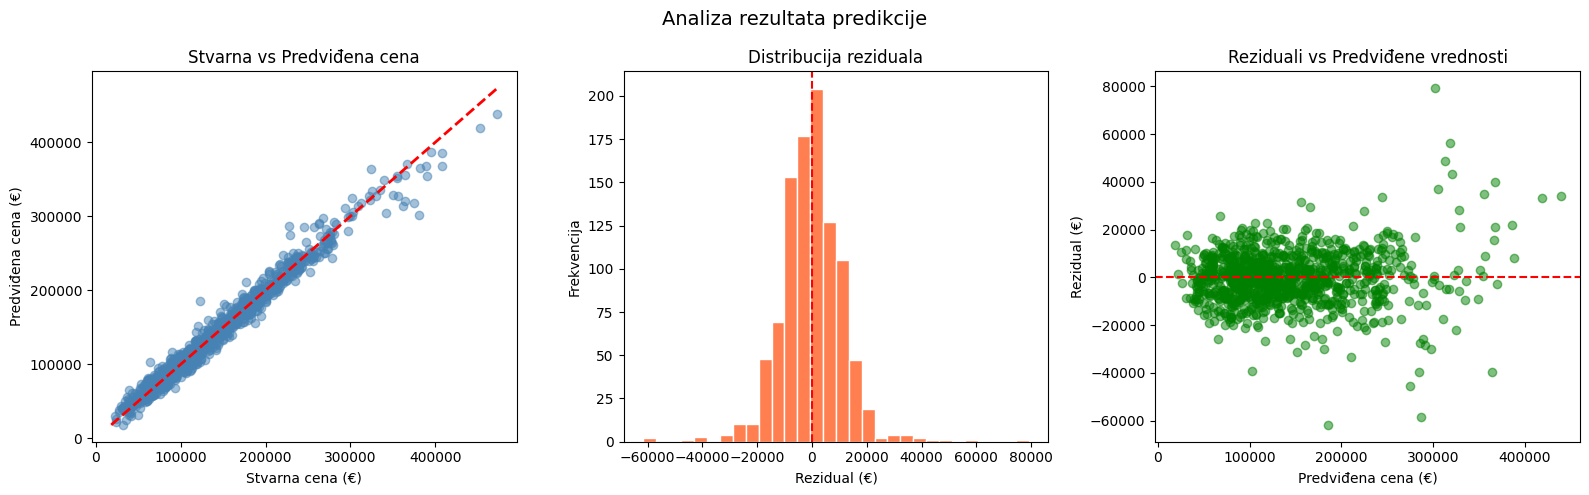

=== FINALNE METRIKE NAJBOLJEG MODELA ===
  R²   = 0.9752
  MAE  = 8,295 €
  RMSE = 11,348 €
  MAPE = 7.22 %


In [11]:
# ============================================================
# KORAK 9: ANALIZA REZULTATA PREDIKCIJE
# ============================================================

y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Analiza rezultata predikcije", fontsize=14)

# 1. Stvarne vs predviđene vrednosti
axes[0].scatter(y_test, y_pred_best, alpha=0.5, color="steelblue")
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
axes[0].set_xlabel("Stvarna cena (€)")
axes[0].set_ylabel("Predviđena cena (€)")
axes[0].set_title("Stvarna vs Predviđena cena")

# 2. Distribucija reziduala
axes[1].hist(residuals, bins=30, color="coral", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Rezidual (€)")
axes[1].set_ylabel("Frekvencija")
axes[1].set_title("Distribucija reziduala")

# 3. Reziduali vs predviđene vrednosti
axes[2].scatter(y_pred_best, residuals, alpha=0.5, color="green")
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Predviđena cena (€)")
axes[2].set_ylabel("Rezidual (€)")
axes[2].set_title("Reziduali vs Predviđene vrednosti")

plt.tight_layout()
plt.show()

# Tabela metrika
print("=== FINALNE METRIKE NAJBOLJEG MODELA ===")
print(f"  R²   = {r2_score(y_test, y_pred_best):.4f}")
print(f"  MAE  = {mean_absolute_error(y_test, y_pred_best):,.0f} €")
print(f"  RMSE = {mean_squared_error(y_test, y_pred_best)**0.5:,.0f} €")
print(f"  MAPE = {(abs(residuals/y_test)).mean()*100:.2f} %")

=== VAŽNOST ATRIBUTA ===
              Feature  Importance
              Area_m2      0.5526
  Location_Predgradje      0.1036
   Location_Periferia      0.0970
    PropertyType_Vila      0.0767
            Condition      0.0666
       Location_Zemun      0.0414
  PropertyType_Studio      0.0211
    PropertyType_Stan      0.0183
Location_Novi Beograd      0.0072
            YearBuilt      0.0049
             Bedrooms      0.0025
        ParkingSpaces      0.0023
      Location_Vracar      0.0018
            Renovated      0.0014
          HasBasement      0.0013
            Furnished      0.0006
            Bathrooms      0.0006


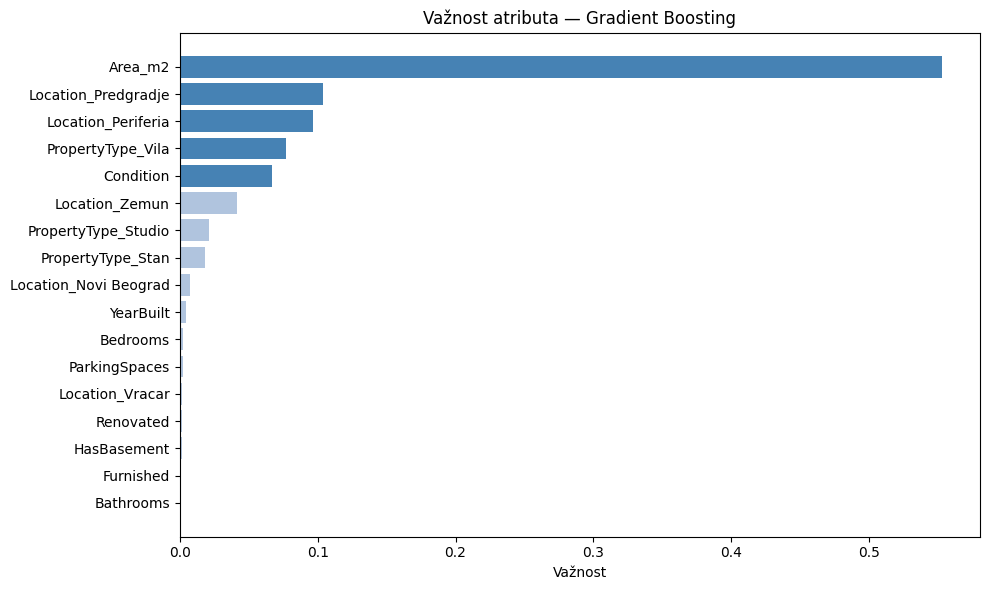


TOP 5 atributa: ['Area_m2', 'Location_Predgradje', 'Location_Periferia', 'PropertyType_Vila', 'Condition']

=== POREĐENJE: SVI ATRIBUTI vs TOP 5 ===
Metrika     Svi atributi           TOP 5
----------------------------------------
R²                0.9547          0.8657
MAE               11,336 €        19,306 €
RMSE              16,682 €        26,378 €


In [12]:
# ============================================================
# KORAK 10: VAŽNOST ATRIBUTA (Feature Importance)
# ============================================================

# --- 1. Feature importance iz Gradient Boosting modela ---
importances = best_model.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("=== VAŽNOST ATRIBUTA ===")
print(feat_df.round(4).to_string(index=False))

# Vizualizacija
plt.figure(figsize=(10, 6))
colors = ["steelblue" if i < 5 else "lightsteelblue" for i in range(len(feat_df))]
plt.barh(feat_df["Feature"][::-1], feat_df["Importance"][::-1], color=colors[::-1])
plt.xlabel("Važnost")
plt.title("Važnost atributa — Gradient Boosting")
plt.tight_layout()
plt.show()

# --- 2. Model sa samo TOP 5 atributa ---
top5 = feat_df["Feature"].head(5).tolist()
print(f"\nTOP 5 atributa: {top5}")

X_top5 = X[top5]
X_train5, X_test5, y_train5, y_test5 = train_test_split(
    X_top5, y, test_size=0.2, random_state=42
)

model_top5 = GradientBoostingRegressor(**grid_search.best_params_, random_state=42)
model_top5.fit(X_train5, y_train5)
y_pred5 = model_top5.predict(X_test5)

r2_5   = r2_score(y_test5, y_pred5)
mae_5  = mean_absolute_error(y_test5, y_pred5)
rmse_5 = mean_squared_error(y_test5, y_pred5) ** 0.5

print("\n=== POREĐENJE: SVI ATRIBUTI vs TOP 5 ===")
print(f"{'Metrika':<8} {'Svi atributi':>15} {'TOP 5':>15}")
print("-" * 40)
print(f"{'R²':<8} {0.9547:>15.4f} {r2_5:>15.4f}")
print(f"{'MAE':<8} {11336:>15,.0f} € {mae_5:>13,.0f} €")
print(f"{'RMSE':<8} {16682:>15,.0f} € {rmse_5:>13,.0f} €")

In [15]:
# ============================================================
# UKLANJANJE NEBITNIH ATRIBUTA
# ============================================================

# Atributi sa vaznoscu ispod 0.2%
nebitni = ["Furnished", "Bathrooms", "HasBasement", "Renovated"]
print(f"Atributi za uklanjanje: {nebitni}")

X_reduced = X.drop(columns=nebitni)
print(f"\nBroj atributa pre: {X.shape[1]}")
print(f"Broj atributa posle: {X_reduced.shape[1]}")

# Treniranje modela bez nebitnih atributa
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model_reduced = GradientBoostingRegressor(**grid_search.best_params_, random_state=42)
model_reduced.fit(X_train_r, y_train_r)
y_pred_r = model_reduced.predict(X_test_r)

mae_r  = mean_absolute_error(y_test_r, y_pred_r)
rmse_r = mean_squared_error(y_test_r, y_pred_r) ** 0.5
r2_r   = r2_score(y_test_r, y_pred_r)

print("\n=== POREĐENJE: SVI ATRIBUTI vs BEZ NEBITNIH ===")

Atributi za uklanjanje: ['Furnished', 'Bathrooms', 'HasBasement', 'Renovated']

Broj atributa pre: 17
Broj atributa posle: 13

=== POREĐENJE: SVI ATRIBUTI vs BEZ NEBITNIH ===


In [18]:
print(f"{'R²':<8} {0.9752:>12.4f} {r2_r:>18.4f}")
print(f"{'MAE':<8} {8295:>11,.0f}€ {mae_r:>17,.0f}€")
print(f"{'RMSE':<8} {11348:>11,.0f}€ {rmse_r:>17,.0f}€")

R²             0.9752             0.9733
MAE            8,295€             8,704€
RMSE          11,348€            11,767€


In [16]:
# ============================================================
# KORAK 11: DEPLOYMENT MODELA
# ============================================================

import joblib

# --- 1. Eksportovanje modela i skalera ---
joblib.dump(best_model, "model_nekretnine.pkl")
joblib.dump(scaler, "scaler_nekretnine.pkl")
joblib.dump(X.columns.tolist(), "features_nekretnine.pkl")
print("✓ Model sačuvan: model_nekretnine.pkl")
print("✓ Skaler sačuvan: scaler_nekretnine.pkl")
print("✓ Features sačuvane: features_nekretnine.pkl")

# --- 2. Jednostavan UI za predikciju ---
def predvidi_cenu(area, year_built, furnished, renovated, location,
                  property_type, has_basement, parking, bedrooms, bathrooms, condition):
    
    # Enkodiranje ulaza
    condition_map = {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4}
    locations = ["Novi Beograd", "Periferia", "Predgradje", "Vracar", "Zemun"]
    property_types = ["Stan", "Studio", "Vila"]
    
    input_data = {col: 0 for col in X.columns}
    input_data["Area_m2"] = area
    input_data["YearBuilt"] = year_built
    input_data["Furnished"] = 1 if furnished == "Yes" else 0
    input_data["Renovated"] = 1 if renovated == "Yes" else 0
    input_data["HasBasement"] = 1 if has_basement == "Yes" else 0
    input_data["ParkingSpaces"] = parking
    input_data["Bedrooms"] = bedrooms
    input_data["Bathrooms"] = bathrooms
    input_data["Condition"] = condition_map[condition]
    
    if location in locations:
        input_data[f"Location_{location}"] = 1
    if property_type in property_types:
        input_data[f"PropertyType_{property_type}"] = 1
    
    df_input = pd.DataFrame([input_data])
    cena = best_model.predict(df_input)[0]
    return round(cena, -2)

# --- 3. Testiranje ---
print("\n=== TEST PREDIKCIJE ===")
primeri = [
    (75, 2010, "Yes", "Yes", "Centar",       "Stan",   "No",  1, 2, 1, "Good"),
    (120, 1995, "No", "No",  "Predgradje",   "Kuca",   "Yes", 2, 3, 2, "Fair"),
    (45,  2020, "Yes","No",  "Novi Beograd", "Studio", "No",  0, 1, 1, "Excellent"),
    (200, 2005, "Yes","Yes", "Centar",       "Vila",   "Yes", 3, 4, 3, "Excellent"),
]

for p_args in primeri:
    cena = predvidi_cenu(*p_args)
    print(f"  {p_args[5]:<8} | {p_args[0]}m² | {p_args[4]:<15} | {p_args[10]:<10} → {cena:>10,.0f} EUR")

✓ Model sačuvan: model_nekretnine.pkl
✓ Skaler sačuvan: scaler_nekretnine.pkl
✓ Features sačuvane: features_nekretnine.pkl

=== TEST PREDIKCIJE ===
  Stan     | 75m² | Centar          | Good       →    197,200 EUR
  Kuca     | 120m² | Predgradje      | Fair       →    136,000 EUR
  Studio   | 45m² | Novi Beograd    | Excellent  →    114,800 EUR
  Vila     | 200m² | Centar          | Excellent  →    521,400 EUR


In [17]:

# --- Interaktivni UI pomoću input() ---

print("=" * 45)
print("   KALKULATOR CENE NEKRETNINE")
print("=" * 45)

print("\nUnesite podatke o nekretnini:\n")

area       = float(input("Površina (m²) [npr. 75]: "))
year       = int(input("Godina izgradnje [npr. 2005]: "))
furnished  = input("Namešteno? (Yes/No): ").strip().capitalize()
renovated  = input("Renovirano? (Yes/No): ").strip().capitalize()
basement   = input("Podrum? (Yes/No): ").strip().capitalize()
parking    = int(input("Broj parking mesta (0-3): "))
bedrooms   = int(input("Broj spavaćih soba (1-5): "))
bathrooms  = int(input("Broj kupatila (1-3): "))

print("\nLokacije: Centar, Novi Beograd, Vracar, Zemun, Periferia, Predgradje")
location   = input("Lokacija: ").strip()

print("Tipovi: Stan, Kuca, Studio, Vila")
prop_type  = input("Tip nekretnine: ").strip()

print("Stanje: Poor, Fair, Good, Excellent")
condition  = input("Stanje: ").strip()

cena = predvidi_cenu(area, year, furnished, renovated, location,
                     prop_type, basement, parking, bedrooms, bathrooms, condition)

print("\n" + "=" * 45)
print(f"  Procenjena cena nekretnine:")
print(f"  {cena:,.0f} EUR")
print("=" * 45)

   KALKULATOR CENE NEKRETNINE

Unesite podatke o nekretnini:


Lokacije: Centar, Novi Beograd, Vracar, Zemun, Periferia, Predgradje
Tipovi: Stan, Kuca, Studio, Vila
Stanje: Poor, Fair, Good, Excellent

  Procenjena cena nekretnine:
  192,800 EUR
